# 07 heritability (GREML, fixed)

这个版本重点修 3 类问题：

1. **每个 phenotype 单独和 GRM 样本取交集**，不再直接把整张 pheno/covar 表扔给 GCTA。  
2. **每个 phenotype 单独去掉缺失的 phenotype / covar**，避免 silent mismatch。  
3. **补全失败日志汇总**，把 `stderr tail` 和错误原因整理出来，便于后面批量排查。  

这版默认把 phenotype 过滤条件改成 **non-missing > 50**。  
如果后面想更严格，再把阈值改回去。

In [24]:
from pathlib import Path
import os
import re
import json
import shutil
import subprocess
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
from IPython.display import display

# =========================
# 路径与参数
# =========================
PROJECT_ROOT = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation")

PLINK2 = shutil.which("plink2") or "/mnt/zzbnew/peixunban/zhanghebin/envs/gwas/bin/plink2"
GCTA = shutil.which("gcta64") or "/mnt/zzbnew/peixunban/zhanghebin/envs/gwas/bin/gcta64"

PFILE = PROJECT_ROOT / "data/processed/genotype/CIMA_BGEID_metaMatched"
PHENO_FILE = PROJECT_ROOT / "data/processed/CIMA/phenotype/CIMA_metabolites_lipids_pheno_plink.safe.tsv"
COVAR_FILE = PROJECT_ROOT / "data/processed/meta/CIMA_plink_covariates.tsv"

OUT_DIR = PROJECT_ROOT / "data/results/heritability_greml"
BED_PREFIX = OUT_DIR / "CIMA_BGEID_metaMatched.biallelic"
GRM_PREFIX = OUT_DIR / "CIMA_BGEID_metaMatched.biallelic.autosome"

PER_PHENO_DIR = OUT_DIR / "per_pheno"
LOG_DIR = OUT_DIR / "logs"
TMP_DIR = OUT_DIR / "tmp"

for d in [OUT_DIR, PER_PHENO_DIR, LOG_DIR, TMP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# 并行参数
N_JOBS = 8
THREAD_PER_JOB = 2

# 基本过滤参数
CAT_COVARS = ["SEX"]
Q_COVARS = ["age", "PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10"]

# 这里按你的要求改成 > 50
MIN_NON_MISSING = 50

# 可选：是否对 phenotype 做 inverse normal
DO_RANK_INT = False

# 构建 bed 时的资源
MAKE_BED_THREADS = 8
MAKE_BED_MEMORY_MB = 32000

# 构建 grm 时的资源
MAKE_GRM_THREADS = 16

print("PLINK2:", PLINK2)
print("GCTA:", GCTA)
print("OUT_DIR:", OUT_DIR)

PLINK2: /mnt/zzbnew/peixunban/zhanghebin/envs/gwas/bin/plink2
GCTA: /mnt/zzbnew/peixunban/zhanghebin/envs/gwas/bin/gcta64
OUT_DIR: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/heritability_greml


## Step 1. 基本检查 + 小工具

In [16]:
# =========================
# 基本检查
# =========================
for exe in [PLINK2, GCTA]:
    if not Path(exe).exists():
        raise FileNotFoundError(f"not found: {exe}")

for f in [PHENO_FILE, COVAR_FILE]:
    if not f.exists():
        raise FileNotFoundError(f)

for suffix in [".pgen", ".pvar", ".psam"]:
    fp = Path(str(PFILE) + suffix)
    if not fp.exists():
        raise FileNotFoundError(f"missing genotype file: {fp}")

# =========================
# 小工具
# =========================
def run_cmd(cmd, step_name, log_hint=None):
    print(f"\n[{step_name}]")
    print(" ".join(map(str, cmd)))
    res = subprocess.run(cmd, capture_output=True, text=True)

    print("returncode:", res.returncode)
    if res.stdout:
        print("\n[stdout tail]")
        print(res.stdout[-3000:])
    if res.stderr:
        print("\n[stderr tail]")
        print(res.stderr[-3000:])

    if res.returncode != 0:
        msg = f"{step_name} failed"
        if log_hint is not None:
            msg += f"; see log: {log_hint}"
        raise RuntimeError(msg)

def safe_name(s: str) -> str:
    s = str(s)
    s = re.sub(r"[^A-Za-z0-9._+-]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s or "phenotype"

def read_text_tail(path, n_lines=30):
    path = Path(path)
    if not path.exists():
        return ""
    try:
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            lines = f.readlines()
        return "".join(lines[-n_lines:]).strip()
    except Exception:
        return ""

def extract_error_message(stderr_tail: str) -> str:
    if not stderr_tail:
        return ""
    lines = [x.strip() for x in stderr_tail.splitlines() if x.strip()]
    if not lines:
        return ""
    # 优先找明显报错
    for line in reversed(lines):
        low = line.lower()
        if any(k in low for k in ["error", "failed", "invalid", "cannot", "problem", "warning"]):
            return line
    return lines[-1]

def rank_inverse_normal(series: pd.Series) -> pd.Series:
    # 不依赖 scipy 的近似实现；如果环境里有 scipy，可以自行替换
    x = series.copy()
    mask = x.notna()
    if mask.sum() == 0:
        return x
    ranks = x[mask].rank(method="average")
    p = (ranks - 0.5) / mask.sum()
    # Abramowitz-Stegun 逆正态近似，避免强依赖 scipy
    # 这里直接调用 pandas/numpy 不方便精确实现，所以简单走 probit 近似需要 scipy。
    # 为了 notebook 可直接运行，这里默认不启用 DO_RANK_INT。
    raise RuntimeError("DO_RANK_INT=True 需要安装 scipy，当前 notebook 默认关闭。")

def parse_hsq(hsq_path: Path):
    rec = {
        "n": np.nan,
        "vg": np.nan,
        "ve": np.nan,
        "vp": np.nan,
        "h2": np.nan,
        "h2_se": np.nan,
        "pval": np.nan,
        "logL": np.nan,
    }
    if not hsq_path.exists():
        return rec

    with open(hsq_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 2:
                continue

            key = parts[0]
            if key == "V(G)":
                rec["vg"] = float(parts[1])
            elif key == "V(e)":
                rec["ve"] = float(parts[1])
            elif key == "Vp":
                rec["vp"] = float(parts[1])
            elif key == "V(G)/Vp":
                rec["h2"] = float(parts[1])
                if len(parts) >= 3:
                    rec["h2_se"] = float(parts[2])
            elif key == "Pval":
                rec["pval"] = float(parts[1])
            elif key == "logL":
                rec["logL"] = float(parts[1])
            elif key == "n":
                rec["n"] = float(parts[1])
    return rec

def load_grm_ids(grm_prefix: Path) -> pd.DataFrame:
    grm_id = Path(str(grm_prefix) + ".grm.id")
    if not grm_id.exists():
        raise FileNotFoundError(grm_id)
    df = pd.read_csv(grm_id, sep="\s+", header=None, names=["FID", "IID"], dtype=str)
    return df

def ensure_str_id_cols(df: pd.DataFrame, cols=("FID", "IID")) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        out[c] = out[c].astype(str)
    return out

## Step 2. 读取 phenotype / covariate，并先做全局检查

In [17]:
pheno_df = pd.read_csv(PHENO_FILE, sep="\t", dtype={"FID": str, "IID": str})
covar_df = pd.read_csv(COVAR_FILE, sep="\t", dtype={"FID": str, "IID": str})

if not {"FID", "IID"}.issubset(pheno_df.columns):
    raise ValueError("PHENO_FILE 必须包含 FID, IID")
if not {"FID", "IID"}.issubset(covar_df.columns):
    raise ValueError("COVAR_FILE 必须包含 FID, IID")

pheno_df = ensure_str_id_cols(pheno_df)
covar_df = ensure_str_id_cols(covar_df)

missing_cat = [c for c in CAT_COVARS if c not in covar_df.columns]
missing_q = [c for c in Q_COVARS if c not in covar_df.columns]
if missing_cat:
    raise ValueError(f"COVAR_FILE 缺少分类协变量列: {missing_cat}")
if missing_q:
    raise ValueError(f"COVAR_FILE 缺少连续协变量列: {missing_q}")

# 去重：同一个 FID/IID 只保留第一条，避免后面 merge 放大
pheno_dup_n = pheno_df.duplicated(["FID", "IID"]).sum()
covar_dup_n = covar_df.duplicated(["FID", "IID"]).sum()

if pheno_dup_n > 0:
    print(f"[warn] PHENO_FILE duplicated IDs: {pheno_dup_n}, keep first")
    pheno_df = pheno_df.drop_duplicates(["FID", "IID"], keep="first").copy()

if covar_dup_n > 0:
    print(f"[warn] COVAR_FILE duplicated IDs: {covar_dup_n}, keep first")
    covar_df = covar_df.drop_duplicates(["FID", "IID"], keep="first").copy()

pheno_cols = [c for c in pheno_df.columns if c not in ["FID", "IID"]]
print("phenotype count (raw):", len(pheno_cols))

pheno_non_missing = pheno_df[pheno_cols].notna().sum().sort_values(ascending=False)
keep_phenos = pheno_non_missing[pheno_non_missing > MIN_NON_MISSING].index.tolist()

print(f"phenotype count (non-missing > {MIN_NON_MISSING}):", len(keep_phenos))

pheno_manifest = pd.DataFrame({
    "phenotype": pheno_non_missing.index,
    "n_non_missing": pheno_non_missing.values,
    "keep_for_greml": pheno_non_missing.index.isin(keep_phenos)
})
pheno_manifest_file = OUT_DIR / "phenotype_manifest_for_greml.tsv"
pheno_manifest.to_csv(pheno_manifest_file, sep="\t", index=False)
print("saved:", pheno_manifest_file)

display(pheno_manifest.head())

phenotype count (raw): 1549
phenotype count (non-missing > 50): 1531
saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/heritability_greml_fixed/phenotype_manifest_for_greml.tsv


,phenotype,n_non_missing,keep_for_greml
0,P_2_Aminoisobutyric_acid,390,True
1,PI_16_0_18_2,390,True
2,m_Coumaric_acid,390,True
3,TAG54_0_FA16_0,390,True
4,TAG54_4_FA18_0,390,True


## Step 3. 构建 biallelic SNP bed + autosome GRM

这里只做一次。已经存在就跳过。

In [18]:
bed_exists = (
    BED_PREFIX.with_suffix(".bed").exists()
    and BED_PREFIX.with_suffix(".bim").exists()
    and BED_PREFIX.with_suffix(".fam").exists()
)

if not bed_exists:
    cmd = [
        str(PLINK2),
        "--pfile", str(PFILE),
        "--chr", "1-22",
        "--max-alleles", "2",
        "--snps-only", "just-acgt",
        "--make-bed",
        "--out", str(BED_PREFIX),
        "--threads", str(MAKE_BED_THREADS),
        "--memory", str(MAKE_BED_MEMORY_MB),
    ]
    run_cmd(cmd, "make-bed(biallelic SNP only)", log_hint=str(BED_PREFIX) + ".log")
else:
    print("[make-bed] exists, skip")

grm_exists = (
    Path(str(GRM_PREFIX) + ".grm.bin").exists()
    and Path(str(GRM_PREFIX) + ".grm.N.bin").exists()
    and Path(str(GRM_PREFIX) + ".grm.id").exists()
)

if not grm_exists:
    cmd = [
        str(GCTA),
        "--bfile", str(BED_PREFIX),
        "--make-grm",
        "--out", str(GRM_PREFIX),
        "--thread-num", str(MAKE_GRM_THREADS),
    ]
    run_cmd(cmd, "make-grm", log_hint=str(GRM_PREFIX) + ".log")
else:
    print("[make-grm] exists, skip")


[make-bed(biallelic SNP only)]
/mnt/zzbnew/peixunban/zhanghebin/envs/gwas/bin/plink2 --pfile /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID_metaMatched --chr 1-22 --max-alleles 2 --snps-only just-acgt --make-bed --out /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/heritability_greml_fixed/CIMA_BGEID_metaMatched.biallelic --threads 8 --memory 32000
returncode: 0

[stdout tail]
PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/heritability_greml_fixed/CIMA_BGEID_metaMatched.biallelic.log.
Options in effect:
  --chr 1-22
  --make-bed
  --max-alleles 2
  --memory 32000
  --out /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/heritability_greml_fixed/CIMA_BGEID_metaMatched.biallelic
  --pfile /mnt/zzbnew/

## Step 4. 读取 GRM ID，并检查全局样本交集

这里是这版最关键的修复点：  
后面每个 phenotype 都只在 **GRM ∩ phenotype 非缺失 ∩ covariate 非缺失** 的样本上运行。

In [19]:
grm_id_df = load_grm_ids(GRM_PREFIX)
grm_id_df = ensure_str_id_cols(grm_id_df)

print("GRM sample count:", len(grm_id_df))

pheno_id_df = pheno_df[["FID", "IID"]].drop_duplicates().copy()
covar_id_df = covar_df[["FID", "IID"]].drop_duplicates().copy()

grm_key = set(zip(grm_id_df["FID"], grm_id_df["IID"]))
pheno_key = set(zip(pheno_id_df["FID"], pheno_id_df["IID"]))
covar_key = set(zip(covar_id_df["FID"], covar_id_df["IID"]))

print("in GRM only:", len(grm_key - pheno_key), "(vs phenotype table)")
print("in pheno only:", len(pheno_key - grm_key), "(not in GRM)")
print("in covar only:", len(covar_key - grm_key), "(not in GRM)")
print("GRM ∩ pheno:", len(grm_key & pheno_key))
print("GRM ∩ covar:", len(grm_key & covar_key))

# 预先保留 GRM 样本范围内的 covar，后面每个 phenotype 再按缺失过滤
covar_in_grm = covar_df.merge(grm_id_df, on=["FID", "IID"], how="inner").copy()

covar_complete_mask = covar_in_grm[CAT_COVARS + Q_COVARS].notna().all(axis=1)
covar_complete_df = covar_in_grm.loc[covar_complete_mask, ["FID", "IID"] + CAT_COVARS + Q_COVARS].copy()

print("covar rows in GRM:", len(covar_in_grm))
print("covar complete rows in GRM:", len(covar_complete_df))

global_sample_manifest = (
    grm_id_df
    .merge(pheno_id_df.assign(in_pheno=1), on=["FID", "IID"], how="left")
    .merge(covar_id_df.assign(in_covar=1), on=["FID", "IID"], how="left")
    .merge(covar_complete_df[["FID", "IID"]].assign(covar_complete=1), on=["FID", "IID"], how="left")
)

for c in ["in_pheno", "in_covar", "covar_complete"]:
    global_sample_manifest[c] = global_sample_manifest[c].fillna(0).astype(int)

global_sample_manifest_file = OUT_DIR / "global_sample_manifest.tsv"
global_sample_manifest.to_csv(global_sample_manifest_file, sep="\t", index=False)
print("saved:", global_sample_manifest_file)

display(global_sample_manifest.head())

GRM sample count: 443
in GRM only: 72 (vs phenotype table)
in pheno only: 19 (not in GRM)
in covar only: 0 (not in GRM)
GRM ∩ pheno: 371
GRM ∩ covar: 443
covar rows in GRM: 443
covar complete rows in GRM: 443
saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/heritability_greml_fixed/global_sample_manifest.tsv


,FID,IID,in_pheno,in_covar,covar_complete
0,E-B21100458292,E-B21100458292,0,1,1
1,E-B21103279967,E-B21103279967,0,1,1
2,E-B21105477143,E-B21105477143,0,1,1
3,E-B21106356138,E-B21106356138,0,1,1
4,E-B21106792844,E-B21106792844,0,1,1


## Step 5. 单 phenotype 运行函数

每个 phenotype 会做这些事：

- 从 `GRM ID` 开始取样本宇宙  
- 只保留该 phenotype 非缺失的样本  
- 再去掉缺失 covariate 的样本  
- 导出 phenotype / covar / qcovar / keep 文件  
- 跑 GCTA REML  
- 把 stdout / stderr / tail / error_message 全记下来  

这样失败时能直接查。

In [20]:
def run_one(pheno: str):
    sname = safe_name(pheno)
    ph_dir = PER_PHENO_DIR / sname
    ph_dir.mkdir(parents=True, exist_ok=True)

    one_pheno_file = ph_dir / f"{sname}.pheno.tsv"
    one_covar_file = ph_dir / f"{sname}.covar.tsv"
    one_qcovar_file = ph_dir / f"{sname}.qcovar.tsv"
    one_keep_file = ph_dir / f"{sname}.keep.tsv"
    one_sample_manifest = ph_dir / f"{sname}.sample_manifest.tsv"

    out_prefix = ph_dir / sname
    hsq_file = ph_dir / f"{sname}.hsq"
    stdout_log = LOG_DIR / f"{sname}.stdout.log"
    stderr_log = LOG_DIR / f"{sname}.stderr.log"

    if hsq_file.exists():
        parsed = parse_hsq(hsq_file)
        return {
            "phenotype": pheno,
            "status": "skip_exists",
            "out_prefix": str(out_prefix),
            "n_model": parsed["n"],
            "stderr_file": str(stderr_log),
            "stdout_file": str(stdout_log),
            "error_message": "",
            "tail_message": read_text_tail(stderr_log, n_lines=20),
        }

    # phenotype 非缺失样本
    ph_sub = pheno_df.loc[:, ["FID", "IID", pheno]].copy()
    ph_sub = ph_sub[ph_sub[pheno].notna()].copy()

    # 如果启用 INT，在这里做
    if DO_RANK_INT:
        raise RuntimeError("当前 notebook 默认 DO_RANK_INT=False；如需启用，请先安装 scipy 再改。")

    # 先与 GRM 相交
    ph_sub = ph_sub.merge(grm_id_df, on=["FID", "IID"], how="inner")

    # 再与完整 covar 相交
    merged = (
        ph_sub
        .merge(covar_complete_df, on=["FID", "IID"], how="inner")
        .copy()
    )

    # 记录样本情况
    manifest = grm_id_df.copy()
    manifest["in_pheno_non_missing"] = manifest.set_index(["FID", "IID"]).index.isin(
        ph_sub.set_index(["FID", "IID"]).index
    ).astype(int)
    manifest["in_final_model"] = manifest.set_index(["FID", "IID"]).index.isin(
        merged.set_index(["FID", "IID"]).index
    ).astype(int)
    manifest.to_csv(one_sample_manifest, sep="\t", index=False)

    n_non_missing = int(ph_sub.shape[0])
    n_model = int(merged.shape[0])

    if n_model <= 1:
        msg = f"too_few_samples_after_intersection: {n_model}"
        Path(stderr_log).write_text(msg + "\n", encoding="utf-8")
        return {
            "phenotype": pheno,
            "status": "failed_precheck_too_few_samples",
            "out_prefix": str(out_prefix),
            "n_model": n_model,
            "stderr_file": str(stderr_log),
            "stdout_file": str(stdout_log),
            "error_message": msg,
            "tail_message": msg,
        }

    # 输出文件：GCTA 的 pheno/covar/qcovar 最稳妥还是都导出成当前 phenotype 子集
    pheno_export = merged[["FID", "IID", pheno]].copy()
    covar_export = merged[["FID", "IID"] + CAT_COVARS].copy()
    qcovar_export = merged[["FID", "IID"] + Q_COVARS].copy()
    keep_export = merged[["FID", "IID"]].copy()

    pheno_export.to_csv(one_pheno_file, sep="\t", index=False)
    covar_export.to_csv(one_covar_file, sep="\t", index=False)
    qcovar_export.to_csv(one_qcovar_file, sep="\t", index=False)
    keep_export.to_csv(one_keep_file, sep="\t", index=False, header=False)

    cmd = [
        str(GCTA),
        "--grm", str(GRM_PREFIX),
        "--keep", str(one_keep_file),
        "--pheno", str(one_pheno_file),
        "--reml",
        # "--reml-no-constrain",这个参数允许方差分量变成负数。部分phenotype 上，AI-REML 很快就走进了负残差方差区域，然后直接发散
        "--covar", str(one_covar_file),
        "--qcovar", str(one_qcovar_file),
        "--out", str(out_prefix),
        "--thread-num", str(THREAD_PER_JOB),
    ]

    try:
        with open(stdout_log, "w", encoding="utf-8") as fout, open(stderr_log, "w", encoding="utf-8") as ferr:
            ret = subprocess.run(cmd, stdout=fout, stderr=ferr)

        stderr_tail = read_text_tail(stderr_log, n_lines=30)
        error_message = extract_error_message(stderr_tail)

        if ret.returncode == 0 and hsq_file.exists():
            status = "ok"
        else:
            status = f"failed_returncode_{ret.returncode}"

        return {
            "phenotype": pheno,
            "status": status,
            "out_prefix": str(out_prefix),
            "n_non_missing_after_grm": n_non_missing,
            "n_model": n_model,
            "stderr_file": str(stderr_log),
            "stdout_file": str(stdout_log),
            "error_message": error_message,
            "tail_message": stderr_tail,
        }

    except Exception as e:
        msg = f"exception: {e}"
        Path(stderr_log).write_text(msg + "\n", encoding="utf-8")
        return {
            "phenotype": pheno,
            "status": "exception",
            "out_prefix": str(out_prefix),
            "n_non_missing_after_grm": n_non_missing,
            "n_model": n_model,
            "stderr_file": str(stderr_log),
            "stdout_file": str(stdout_log),
            "error_message": msg,
            "tail_message": msg,
        }

## Step 6. 并行运行 GREML

In [21]:
print("[run greml]")
run_records = []

with ThreadPoolExecutor(max_workers=N_JOBS) as ex:
    futs = {ex.submit(run_one, ph): ph for ph in keep_phenos}
    total = len(futs)

    for i, fut in enumerate(as_completed(futs), 1):
        rec = fut.result()
        run_records.append(rec)

        if i % 20 == 0 or i == total:
            ok_n = sum(r["status"] in {"ok", "skip_exists"} for r in run_records)
            fail_n = i - ok_n
            print(f"done {i}/{total} | ok_or_skip={ok_n} | fail={fail_n}")

run_df = pd.DataFrame(run_records)
run_status_file = OUT_DIR / "run_status.tsv"
run_df.to_csv(run_status_file, sep="\t", index=False)
print("saved:", run_status_file)

display(run_df.head())

[run greml]
done 20/1531 | ok_or_skip=20 | fail=0
done 40/1531 | ok_or_skip=40 | fail=0
done 60/1531 | ok_or_skip=60 | fail=0
done 80/1531 | ok_or_skip=80 | fail=0
done 100/1531 | ok_or_skip=100 | fail=0
done 120/1531 | ok_or_skip=120 | fail=0
done 140/1531 | ok_or_skip=140 | fail=0
done 160/1531 | ok_or_skip=160 | fail=0
done 180/1531 | ok_or_skip=180 | fail=0
done 200/1531 | ok_or_skip=200 | fail=0
done 220/1531 | ok_or_skip=220 | fail=0
done 240/1531 | ok_or_skip=240 | fail=0
done 260/1531 | ok_or_skip=260 | fail=0
done 280/1531 | ok_or_skip=280 | fail=0
done 300/1531 | ok_or_skip=300 | fail=0
done 320/1531 | ok_or_skip=320 | fail=0
done 340/1531 | ok_or_skip=340 | fail=0
done 360/1531 | ok_or_skip=360 | fail=0
done 380/1531 | ok_or_skip=380 | fail=0
done 400/1531 | ok_or_skip=400 | fail=0
done 420/1531 | ok_or_skip=420 | fail=0
done 440/1531 | ok_or_skip=440 | fail=0
done 460/1531 | ok_or_skip=460 | fail=0
done 480/1531 | ok_or_skip=480 | fail=0
done 500/1531 | ok_or_skip=500 | fai

,phenotype,status,out_prefix,n_non_missing_after_grm,n_model,stderr_file,stdout_file,error_message,tail_message
0,TAG54_4_FA18_3,ok,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,371,371,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,,
1,TAG54_0_FA16_0,ok,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,371,371,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,,
2,TAG54_4_FA18_1,ok,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,371,371,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,,
3,m_Coumaric_acid,ok,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,371,371,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,,
4,TAG54_4_FA18_0,ok,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,371,371,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,,


## Step 7. 汇总 hsq 结果

In [22]:
summary_records = []

for ph in keep_phenos:
    sname = safe_name(ph)
    ph_dir = PER_PHENO_DIR / sname
    hsq_file = ph_dir / f"{sname}.hsq"

    sub = run_df.loc[run_df["phenotype"] == ph]
    status = sub["status"].iloc[0] if len(sub) else "missing"
    n_model = sub["n_model"].iloc[0] if ("n_model" in sub.columns and len(sub)) else np.nan
    error_message = sub["error_message"].iloc[0] if ("error_message" in sub.columns and len(sub)) else ""
    tail_message = sub["tail_message"].iloc[0] if ("tail_message" in sub.columns and len(sub)) else ""
    stderr_file = sub["stderr_file"].iloc[0] if ("stderr_file" in sub.columns and len(sub)) else ""
    stdout_file = sub["stdout_file"].iloc[0] if ("stdout_file" in sub.columns and len(sub)) else ""

    rec = {
        "phenotype": ph,
        "n_non_missing_input": int(pheno_non_missing[ph]),
        "n_model": n_model,
        "status": status,
        "stderr_file": stderr_file,
        "stdout_file": stdout_file,
        "error_message": error_message,
        "tail_message": tail_message,
    }
    rec.update(parse_hsq(hsq_file))
    summary_records.append(rec)

summary_df = pd.DataFrame(summary_records)

summary_df["h2_z"] = np.where(
    summary_df["h2_se"].notna() & (summary_df["h2_se"] != 0),
    summary_df["h2"] / summary_df["h2_se"],
    np.nan
)
summary_df["h2_lower95"] = np.where(
    summary_df["h2_se"].notna(),
    summary_df["h2"] - 1.96 * summary_df["h2_se"],
    np.nan
)
summary_df["h2_upper95"] = np.where(
    summary_df["h2_se"].notna(),
    summary_df["h2"] + 1.96 * summary_df["h2_se"],
    np.nan
)

summary_df = summary_df.sort_values(
    ["status", "h2_z", "h2"],
    ascending=[True, False, False]
).reset_index(drop=True)

summary_file = OUT_DIR / "heritability_summary.tsv"
summary_df.to_csv(summary_file, sep="\t", index=False)
print("saved:", summary_file)

print("\n[status counts]")
display(summary_df["status"].value_counts(dropna=False).rename_axis("status").reset_index(name="n"))

print("\n[top 20 by h2_z]")
display(summary_df[summary_df["status"] == "ok"].head(20))

saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/heritability_greml_fixed/heritability_summary.tsv

[status counts]


,status,n
0,ok,1531



[top 20 by h2_z]


,phenotype,n_non_missing_input,n_model,status,stderr_file,stdout_file,error_message,tail_message,n,vg,ve,vp,h2,h2_se,pval,logL,h2_z,h2_lower95,h2_upper95
0,TAG60_12_FA22_6,377,358,ok,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,,,358.0,4.817585,0.000008,4.817593,0.999998,0.863123,0.500000,-539.132,1.158581,-0.691723,2.691719
1,TAG54_8_FA22_6,382,363,ok,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,,,363.0,5.487351,0.000007,5.487358,0.999999,0.946750,0.001360,-504.262,1.056244,-0.855631,2.855629
2,TAG60_11_FA22_6,362,343,ok,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,,,343.0,1.434798,0.000002,1.434800,0.999999,0.994725,0.002854,-260.700,1.005302,-0.949662,2.949660
3,TAG60_10_FA22_6,372,353,ok,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,,,353.0,0.539692,0.000001,0.539693,0.999999,1.005979,0.002294,-88.038,0.994056,-0.971720,2.971718
4,TAG58_8_FA22_6,386,367,ok,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,,,367.0,46.297965,0.000050,46.298015,0.999999,1.022249,0.013292,-867.167,0.978234,-1.003609,3.003607
5,TAG58_9_FA18_1,388,369,ok,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,,,369.0,3.280034,0.000004,3.280038,0.999999,1.028296,0.007252,-403.173,0.972482,-1.015461,3.015459
6,TAG58_7_FA22_6,387,368,ok,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,,,368.0,5.709634,0.000006,5.709640,0.999999,1.037380,0.027637,-496.628,0.963966,-1.033266,3.033264
7,TAG56_9_FA22_6,385,366,ok,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,,,366.0,19.116081,0.000020,19.116101,0.999999,1.040557,0.011794,-709.198,0.961023,-1.039493,3.039491
8,TAG58_10_FA18_2,385,366,ok,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,,,366.0,3.856903,0.000004,3.856907,0.999999,1.051549,0.006156,-429.828,0.950977,-1.061037,3.061035
9,TAG60_11_FA22_5,359,340,ok,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,,,340.0,0.136990,0.000000,0.136990,0.999999,1.056439,0.003085,139.407,0.946575,-1.070621,3.070619


## Step 8. 失败原因汇总

这一步就是为了快速看为什么还会失败。

In [23]:
failed_df = summary_df[~summary_df["status"].isin(["ok", "skip_exists"])].copy()

failed_reason_summary = (
    failed_df["error_message"]
    .fillna("")
    .replace("", "EMPTY_ERROR_MESSAGE")
    .value_counts()
    .rename_axis("error_message")
    .reset_index(name="count")
)

failed_reason_file = OUT_DIR / "failed_reason_summary.tsv"
failed_reason_summary.to_csv(failed_reason_file, sep="\t", index=False)
print("saved:", failed_reason_file)

print("\n[top error messages]")
display(failed_reason_summary.head(20))

print("\n[failed examples]")
display(
    failed_df.loc[:, [
        "phenotype", "n_non_missing_input", "n_model",
        "status", "error_message", "stderr_file"
    ]].head(20)
)

saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/heritability_greml_fixed/failed_reason_summary.tsv

[top error messages]


,error_message,count



[failed examples]


,phenotype,n_non_missing_input,n_model,status,error_message,stderr_file


## Step 9. 解读

优先看这几个文件：

- `heritability_summary.tsv`
- `failed_reason_summary.tsv`
- `run_status.tsv`
- 每个 phenotype 子目录下的 `*.sample_manifest.tsv`
- 对应 `logs/*.stderr.log`

如果还有大批 phenotype 失败，优先排查：

1. 某些 phenotype 在做完 `GRM ∩ covar complete ∩ non-missing phenotype` 后样本数太小  
2. 某些 phenotype 方差过小 / 常数列  
3. 某些 covariate 实际上在保留下来的样本里退化成常数  
4. 个别 phenotype 的数值格式异常  

如果你后面想继续补强，可以再加两步：

- 在 `run_one()` 里先检查 phenotype 方差是否接近 0  
- 检查每个 covariate 在该 phenotype 子样本里是否变成单一取值  

n_non_missing_input：原始 phenotype 非缺失样本数
n_model：真正进入模型的样本数
n：GCTA 在 .hsq 里报告的样本数，通常应和 n_model 一致
vg：遗传方差 V(G)
ve：残差方差 V(e)
vp：总方差 V
p
	​

=V(G)+V(e)
h2：SNP 遗传力估计 h
2
=V(G)/V
p
	​

h2_se：h2 的标准误
pval：遗传方差是否显著大于 0 的检验 P 值
logL：对数似然
h2_z = h2 / h2_se
h2_lower95, h2_upper95：95% CI

### Heritability GREML 结果质控可视化

这一节对 `heritability_summary.tsv` 做一个整体统计和可视化，先看：

1. 哪些 phenotype 跑成功了；
2. `ok` 结果的 `h2`、`h2_se`、`ve` 分布；
3. 是否存在大量 `ve≈0 / h2≈1 / SE很大` 的边界解；
4. 先把结果分成：
   - failed
   - boundary_suspect
   - unstable
   - relatively_ok

后面再决定哪些 phenotype 值得继续解释。

shape: (1531, 19)
columns: ['phenotype', 'n_non_missing_input', 'n_model', 'status', 'stderr_file', 'stdout_file', 'error_message', 'tail_message', 'n', 'vg', 've', 'vp', 'h2', 'h2_se', 'pval', 'logL', 'h2_z', 'h2_lower95', 'h2_upper95']
saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/heritability_greml/heritability_summary.with_qc_label.tsv

[status counts]
status
ok    1531
Name: count, dtype: int64

[qc_label counts]
qc_label
unstable            866
boundary_suspect    665
Name: count, dtype: int64

ok count: 1531
saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/heritability_greml/heritability_qc_stats.tsv


,metric,value
0,n_total,1531.000000
1,n_ok,1531.000000
2,n_failed,0.000000
3,n_boundary_suspect,665.000000
4,n_unstable,866.000000
5,n_relatively_ok,0.000000
6,median_h2_ok,0.423294
7,median_h2_se_ok,1.358313
8,median_ve_ok,0.093866
9,prop_ve_le_1e-4_ok,0.363161


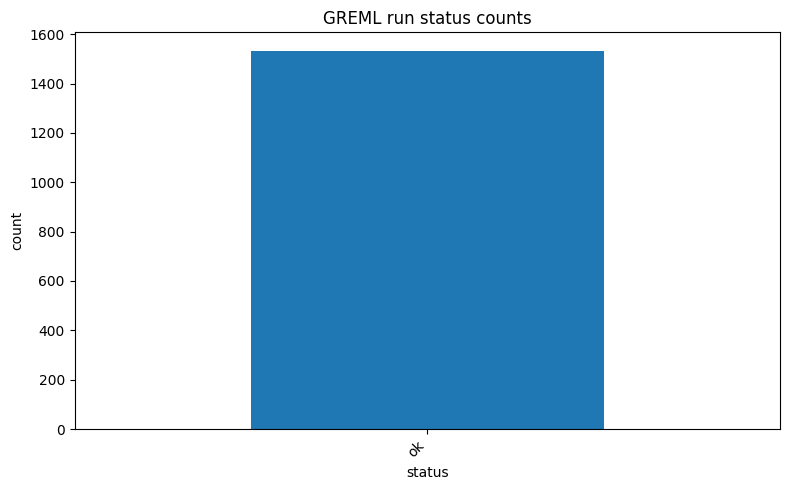

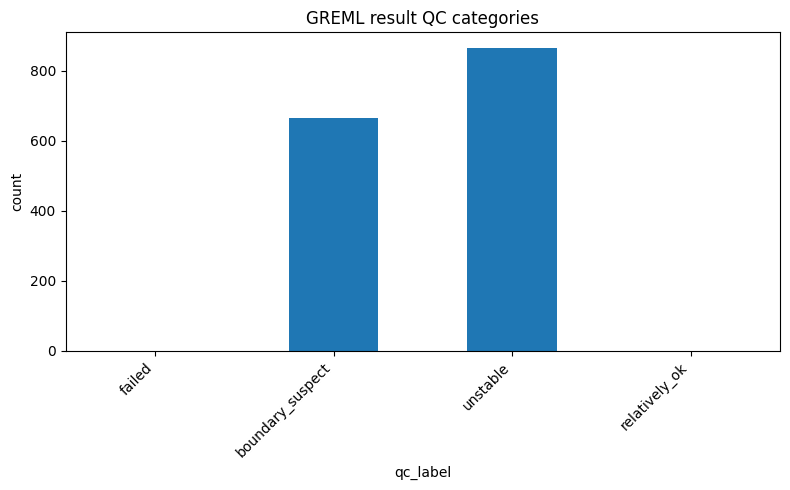

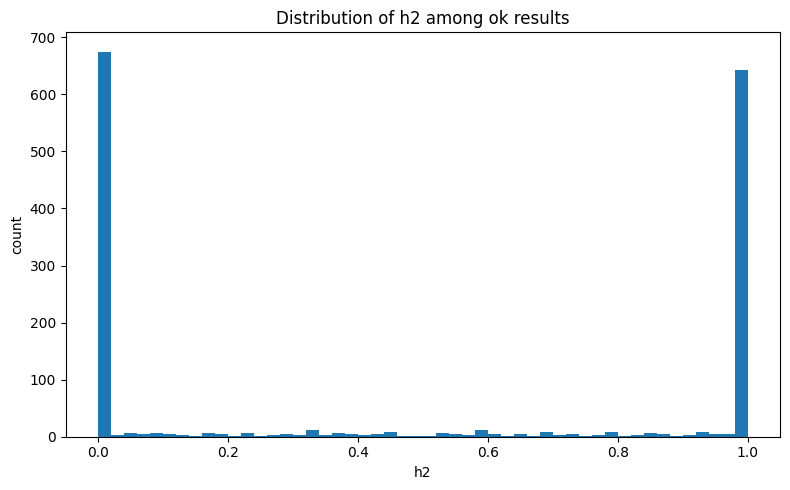

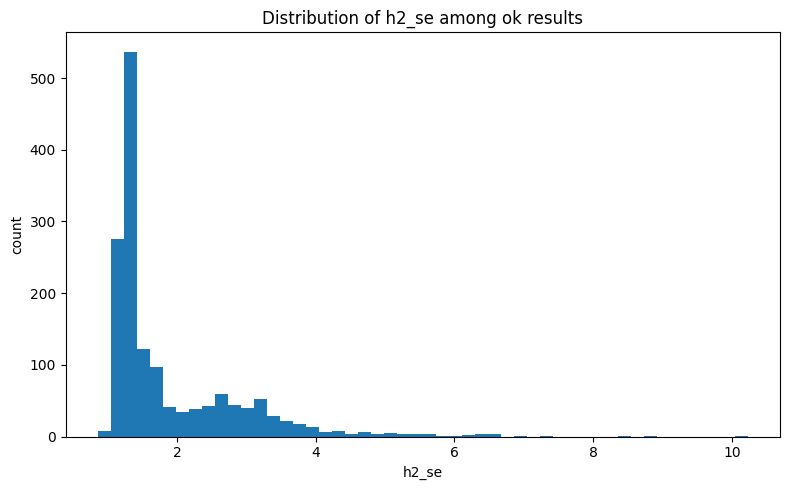

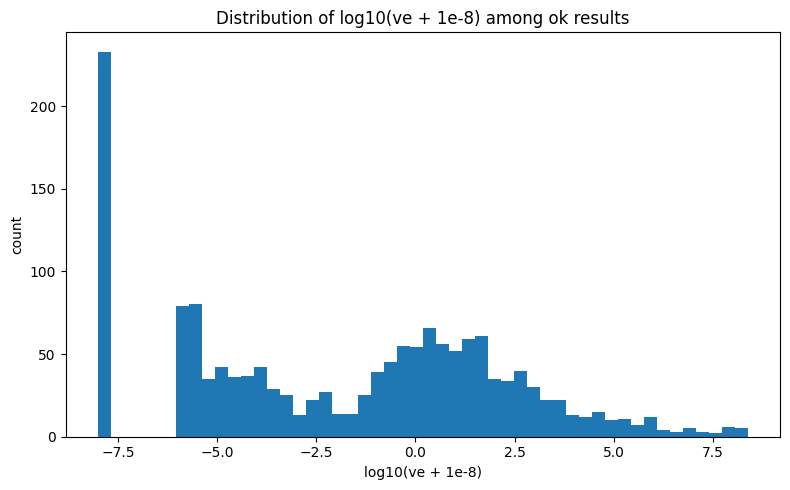

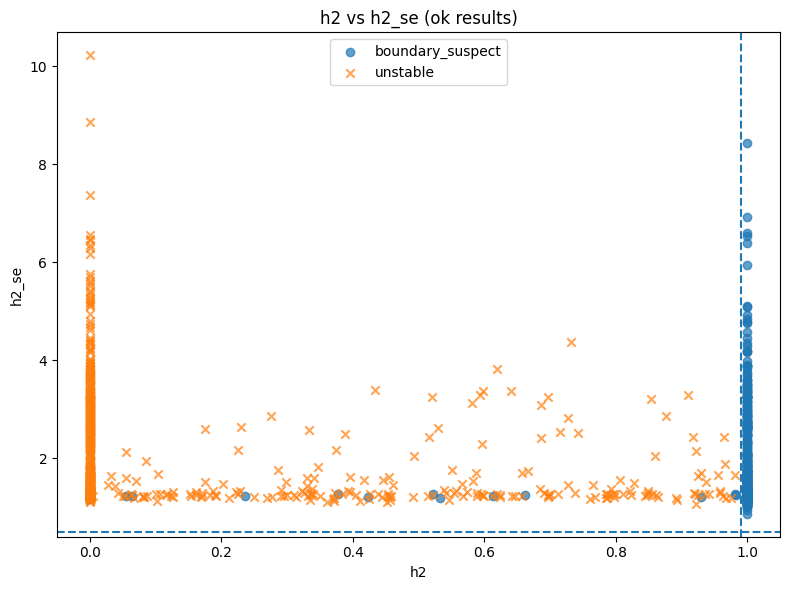

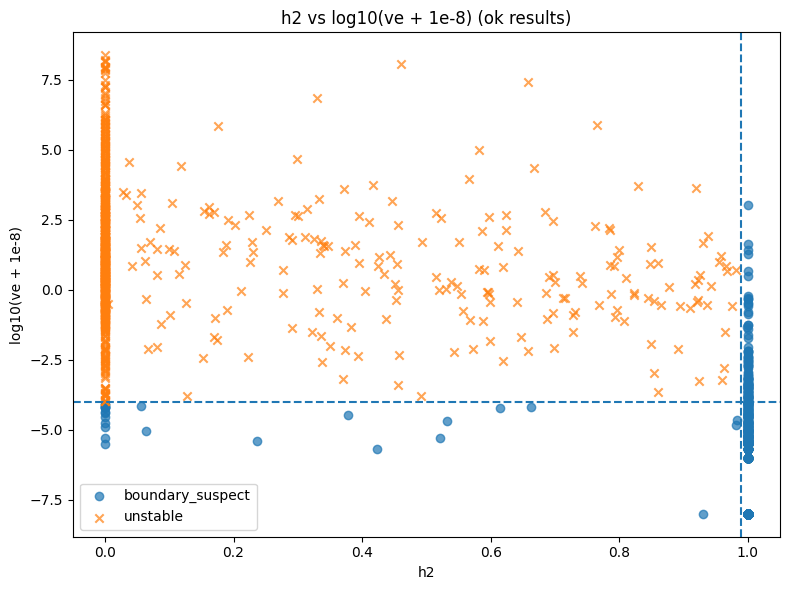


[top 20 most boundary-like]


,phenotype,n_model,vg,ve,vp,h2,h2_se,pval,h2_z,qc_label
805,PG_20_2_20_5,59,0.248098,0.0,0.248098,0.999999,6.388779,0.41994,0.156524,boundary_suspect
798,PE_20_0_22_2,69,0.089016,0.0,0.089016,0.999999,5.933726,0.30890,0.168528,boundary_suspect
781,PE_20_4_20_4,89,0.466509,0.0,0.466509,0.999999,4.843060,0.39907,0.206481,boundary_suspect
770,PE_17_0_17_0,80,0.143280,0.0,0.143281,0.999999,4.456319,0.33623,0.224400,boundary_suspect
751,PE_22_1_22_1,117,0.116205,0.0,0.116205,0.999999,3.909611,0.19052,0.255780,boundary_suspect
736,PE_22_0_22_4,133,0.124447,0.0,0.124447,0.999999,3.680391,0.37178,0.271710,boundary_suspect
733,PE_18_4_18_4,124,0.021838,0.0,0.021838,0.999999,3.594624,0.34616,0.278193,boundary_suspect
729,PE_16_1_18_3,137,0.174076,0.0,0.174077,0.999999,3.540161,0.17231,0.282473,boundary_suspect
726,PE_22_2_22_2,129,0.076250,0.0,0.076251,0.999999,3.504513,0.24776,0.285346,boundary_suspect
723,PE_18_3_18_3,125,0.041377,0.0,0.041377,0.999999,3.489477,0.17439,0.286576,boundary_suspect



[top 20 relatively_ok by h2_z]
No relatively_ok phenotype under current thresholds.

all plots saved to: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/heritability_greml/qc_plots


In [26]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 路径
# =========================
SUMMARY_FILE = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/heritability_greml/heritability_summary.tsv")
OUT_DIR = SUMMARY_FILE.parent / "qc_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# 读入数据
# =========================
df = pd.read_csv(SUMMARY_FILE, sep="\t")
print("shape:", df.shape)
print("columns:", df.columns.tolist())

# 数值列转 numeric，防止读成字符串
num_cols = [
    "n_non_missing_input", "n_model", "n",
    "vg", "ve", "vp", "h2", "h2_se", "pval", "logL",
    "h2_z", "h2_lower95", "h2_upper95"
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# =========================
# 结果分类
# =========================
def classify_row(r):
    status = str(r.get("status", ""))
    if status != "ok":
        return "failed"

    h2 = r.get("h2", np.nan)
    h2_se = r.get("h2_se", np.nan)
    ve = r.get("ve", np.nan)
    h2_z = r.get("h2_z", np.nan)
    lower = r.get("h2_lower95", np.nan)
    upper = r.get("h2_upper95", np.nan)

    # 边界可疑：ve 非常小，或 h2 贴近 1
    if pd.notna(ve) and ve <= 1e-4:
        return "boundary_suspect"
    if pd.notna(h2) and h2 >= 0.99:
        return "boundary_suspect"

    # 不稳定：SE 大、Z 小、CI 很宽
    if pd.notna(h2_se) and h2_se >= 0.5:
        return "unstable"
    if pd.notna(h2_z) and h2_z < 2:
        return "unstable"
    if pd.notna(lower) and lower < 0:
        return "unstable"
    if pd.notna(upper) and upper > 1:
        return "unstable"

    return "relatively_ok"

df["qc_label"] = df.apply(classify_row, axis=1)

# 保存带标签表
qc_file = SUMMARY_FILE.parent / "heritability_summary.with_qc_label.tsv"
df.to_csv(qc_file, sep="\t", index=False)
print("saved:", qc_file)

# =========================
# 基本统计
# =========================
print("\n[status counts]")
print(df["status"].value_counts(dropna=False))

print("\n[qc_label counts]")
print(df["qc_label"].value_counts(dropna=False))

ok_df = df[df["status"] == "ok"].copy()
print("\nok count:", len(ok_df))

if len(ok_df) == 0:
    raise ValueError("没有 status == 'ok' 的结果，先检查上游输出。")

# =========================
# 导出一个简单统计表
# =========================
summary_stats = pd.DataFrame({
    "metric": [
        "n_total",
        "n_ok",
        "n_failed",
        "n_boundary_suspect",
        "n_unstable",
        "n_relatively_ok",
        "median_h2_ok",
        "median_h2_se_ok",
        "median_ve_ok",
        "prop_ve_le_1e-4_ok",
        "prop_h2_ge_0.99_ok"
    ],
    "value": [
        len(df),
        (df["status"] == "ok").sum(),
        (df["status"] != "ok").sum(),
        (df["qc_label"] == "boundary_suspect").sum(),
        (df["qc_label"] == "unstable").sum(),
        (df["qc_label"] == "relatively_ok").sum(),
        ok_df["h2"].median(),
        ok_df["h2_se"].median(),
        ok_df["ve"].median(),
        (ok_df["ve"] <= 1e-4).mean(),
        (ok_df["h2"] >= 0.99).mean(),
    ]
})
stats_file = SUMMARY_FILE.parent / "heritability_qc_stats.tsv"
summary_stats.to_csv(stats_file, sep="\t", index=False)
print("saved:", stats_file)

display(summary_stats)

# =========================
# 图 1: status 柱状图
# =========================
status_counts = df["status"].value_counts(dropna=False)

plt.figure(figsize=(8, 5))
status_counts.plot(kind="bar")
plt.title("GREML run status counts")
plt.xlabel("status")
plt.ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUT_DIR / "01_status_counts.png", dpi=200)
plt.show()

# =========================
# 图 2: qc_label 柱状图
# =========================
qc_order = ["failed", "boundary_suspect", "unstable", "relatively_ok"]
qc_counts = df["qc_label"].value_counts().reindex(qc_order).fillna(0)

plt.figure(figsize=(8, 5))
qc_counts.plot(kind="bar")
plt.title("GREML result QC categories")
plt.xlabel("qc_label")
plt.ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUT_DIR / "02_qc_label_counts.png", dpi=200)
plt.show()

# =========================
# 图 3: h2 直方图（ok）
# =========================
plt.figure(figsize=(8, 5))
x = ok_df["h2"].replace([np.inf, -np.inf], np.nan).dropna()
plt.hist(x, bins=50)
plt.title("Distribution of h2 among ok results")
plt.xlabel("h2")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(OUT_DIR / "03_h2_hist_ok.png", dpi=200)
plt.show()

# =========================
# 图 4: h2_se 直方图（ok）
# =========================
plt.figure(figsize=(8, 5))
x = ok_df["h2_se"].replace([np.inf, -np.inf], np.nan).dropna()
plt.hist(x, bins=50)
plt.title("Distribution of h2_se among ok results")
plt.xlabel("h2_se")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(OUT_DIR / "04_h2_se_hist_ok.png", dpi=200)
plt.show()

# =========================
# 图 5: ve 分布（ok）
# 用 log10(ve + 1e-8) 看更直观
# =========================
ve_plot = ok_df["ve"].replace([np.inf, -np.inf], np.nan).dropna()
plt.figure(figsize=(8, 5))
plt.hist(np.log10(ve_plot + 1e-8), bins=50)
plt.title("Distribution of log10(ve + 1e-8) among ok results")
plt.xlabel("log10(ve + 1e-8)")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(OUT_DIR / "05_log10_ve_hist_ok.png", dpi=200)
plt.show()

# =========================
# 图 6: h2 vs h2_se
# =========================
plot_df = ok_df.loc[:, ["phenotype", "h2", "h2_se", "qc_label"]].copy()
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["h2", "h2_se"])

label_to_marker = {
    "boundary_suspect": "o",
    "unstable": "x",
    "relatively_ok": "^"
}

plt.figure(figsize=(8, 6))
for lab, sub in plot_df.groupby("qc_label"):
    plt.scatter(sub["h2"], sub["h2_se"], alpha=0.7, label=lab, marker=label_to_marker.get(lab, "o"))

plt.axvline(0.99, linestyle="--")
plt.axhline(0.5, linestyle="--")
plt.title("h2 vs h2_se (ok results)")
plt.xlabel("h2")
plt.ylabel("h2_se")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "06_h2_vs_h2se_scatter.png", dpi=200)
plt.show()

# =========================
# 图 7: h2 vs ve
# =========================
plot_df = ok_df.loc[:, ["phenotype", "h2", "ve", "qc_label"]].copy()
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["h2", "ve"])

plt.figure(figsize=(8, 6))
for lab, sub in plot_df.groupby("qc_label"):
    plt.scatter(sub["h2"], np.log10(sub["ve"] + 1e-8), alpha=0.7, label=lab, marker=label_to_marker.get(lab, "o"))

plt.axvline(0.99, linestyle="--")
plt.axhline(np.log10(1e-4 + 1e-8), linestyle="--")
plt.title("h2 vs log10(ve + 1e-8) (ok results)")
plt.xlabel("h2")
plt.ylabel("log10(ve + 1e-8)")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "07_h2_vs_log10ve_scatter.png", dpi=200)
plt.show()

# =========================
# 图 8: top/bottom phenotype 表格
# 先给你看最可疑的边界结果
# =========================
boundary_df = ok_df.sort_values(["ve", "h2_se", "h2"], ascending=[True, False, False]).copy()
boundary_cols = [
    "phenotype", "n_model", "vg", "ve", "vp", "h2", "h2_se", "pval", "h2_z", "qc_label"
]
print("\n[top 20 most boundary-like]")
display(boundary_df[boundary_cols].head(20))

relatively_ok_df = df[df["qc_label"] == "relatively_ok"].copy()
relatively_ok_df = relatively_ok_df.sort_values(["h2_z", "h2"], ascending=[False, False])

print("\n[top 20 relatively_ok by h2_z]")
if len(relatively_ok_df) > 0:
    display(relatively_ok_df[boundary_cols].head(20))
else:
    print("No relatively_ok phenotype under current thresholds.")

print("\nall plots saved to:", OUT_DIR)